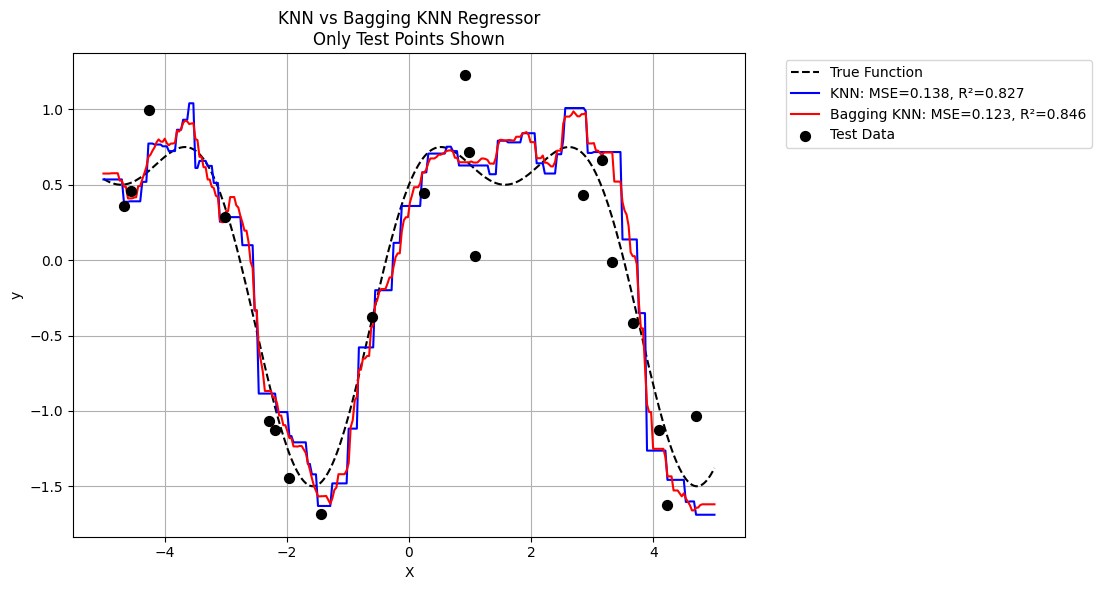

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.metrics import mean_squared_error, r2_score
# 1. Generate 1D nonlinear dataset
np.random.seed(42)
X = np.sort(np.random.rand(80, 1) * 10 - 5, axis=0)  # X ∈ [-5, 5]
true_func = lambda x: np.sin(x) + 0.5 * np.cos(2 * x)
y = true_func(X).ravel() + np.random.normal(0, 0.3, X.shape[0])  # Add noise
# 2. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)
# 3. Define models
knn = KNeighborsRegressor(n_neighbors=3)
bag_knn = BaggingRegressor(estimator=KNeighborsRegressor(n_neighbors=3),
                          n_estimators=30, random_state=0)
# 4. Fit models
knn.fit(X_train, y_train)
bag_knn.fit(X_train, y_train)
# 5. Predict on test data
y_pred_knn = knn.predict(X_test)
y_pred_bag = bag_knn.predict(X_test)
# 6. Evaluation
mse_knn = mean_squared_error(y_test, y_pred_knn)
r2_knn = r2_score(y_test, y_pred_knn)
mse_bag = mean_squared_error(y_test, y_pred_bag)
r2_bag = r2_score(y_test, y_pred_bag)
# 7. Plot smooth prediction line
x_smooth = np.linspace(-5, 5, 300).reshape(-1, 1)
y_true_smooth = true_func(x_smooth).ravel()
y_smooth_knn = knn.predict(x_smooth)
y_smooth_bag = bag_knn.predict(x_smooth)
plt.figure(figsize=(10, 6))
plt.plot(x_smooth, y_true_smooth, 'k--', label="True Function")
plt.plot(x_smooth, y_smooth_knn, 'b-', label=f"KNN: MSE={mse_knn:.3f}, R²={r2_knn:.3f}")
plt.plot(x_smooth, y_smooth_bag, 'r-', label=f"Bagging KNN: MSE={mse_bag:.3f}, R²={r2_bag:.3f}")
# Removed training data scatter
plt.scatter(X_test, y_test, color='black', label="Test Data", s=50, zorder=5)
# Legend outside
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("KNN vs Bagging KNN Regressor\nOnly Test Points Shown")
plt.xlabel("X")
plt.ylabel("y")
plt.grid(True)
plt.tight_layout()
plt.subplots_adjust(right=0.75)
plt.show()